# Decision Trees — Code Examples


### What you will learn:
- 1. How to train a **DecisionTreeClassifier** & **DecisionTreeRegressor**
- 2. Understanding **Features** and data preparation
- 3. How to detect **overfitting** (Train vs Test performance)
- 4. Most Important **Hyperparameters** for regularization
- 5. How to build a **Pipeline**
- 6. How to **viusalize** a tree to explain its rules
- 7. Making a **prediction** on new data
- 8. What **feature importance** tells us


In [39]:
from sklearn.model_selection import GridSearchCV
# --- 1. SETUP & IMPORTS ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-Learn tools
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.metrics import accuracy_score, mean_squared_error, classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Datasets
from sklearn.datasets import load_breast_cancer, load_diabetes

## Part A — Classification with a Decision Tree

**Dataset:** Breast Cancer (Binary classification)
**Goal:** Predict whether a tumor is malignant (1) or benign (0) from cell measurements.

### 1. Understanding Features & Loading Data
Features (X) are the input variables used to make predictions. The target (y) is what we are trying to predict.

In [40]:
# Load the Wisconsin Breast Cancer Dataset
data_cls = load_breast_cancer(as_frame=True)
X_cls = data_cls.data      # Features: matrix of cell measurements
y_cls = data_cls.target    # Target: 0 (Malignant) or 1 (Benign)

# Let's look at the shape of our data
print(f"Total patients (samples): {X_cls.shape[0]}")
print(f"Measurements per patient (features): {X_cls.shape[1]}")
print("\nFirst 5 feature names:", X_cls.columns[:5].tolist())

Total patients (samples): 569
Measurements per patient (features): 30

First 5 feature names: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness']


### 2. Train/Test Split
Before we train a model, we **must** hide some data from it. We train on the 'Training Set' and evaluate on the 'Test Set' to see how well it performs on unseen data.

In [41]:
# Split 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X_cls, 
    y_cls, 
    test_size=0.2,    # 20% reserved for testing
    random_state=42,  # Ensures we get the same split every time we run this
    stratify=y_cls    # Ensures the ratio of 0s and 1s remains balanced
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 455
Testing samples: 114


### 2. Building a Pipeline & Tuning Hyperparameters

A **Pipeline** chains data processing steps (like scaling) and the model together. This prevents data leakage and makes deploying the model easier.

**Most Important Hyperparameters to stop Overfitting:**
- `max_depth`: Limits how deep the tree grows. Deep trees memorize noise.
- `min_samples_split`: Minimum samples needed to create a new branch.
- `min_samples_leaf`: Minimum samples that must end up in a final 'leaf' node.

In [42]:
# Create a Pipeline: Step 1 = Scale Data, Step 2 = Decision Tree
pipeline_dt = Pipeline([
    ('scaler', StandardScaler()),  # Optional for trees, but good practice
    ('model', DecisionTreeClassifier(
        max_depth=3,               # Tuning: Best way to prevent overfitting!
        min_samples_leaf=5,        # Leaves must have at least 5 samples
        random_state=42
    ))
])

# Train the pipeline
pipeline_dt.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


### 3. Prediction & Evaluating Overfitting
If Train Accuracy is 100% but Test Accuracy is 70%, the model **overfit** (memorized the training data). Setting `max_depth=3` above helped us avoid this.

In [43]:
# Predict
y_pred_train = pipeline_dt.predict(X_train)
y_pred_test = pipeline_dt.predict(X_test)

# Evaluate
print("Train Accuracy:", round(accuracy_score(y_train, y_pred_train), 3))
print("Test Accuracy: ", round(accuracy_score(y_test, y_pred_test), 3))

Train Accuracy: 0.974
Test Accuracy:  0.939


### 4. How to Visualize the Tree
Visualizing the tree helps students understand *how* the AI makes decisions inside the black box.

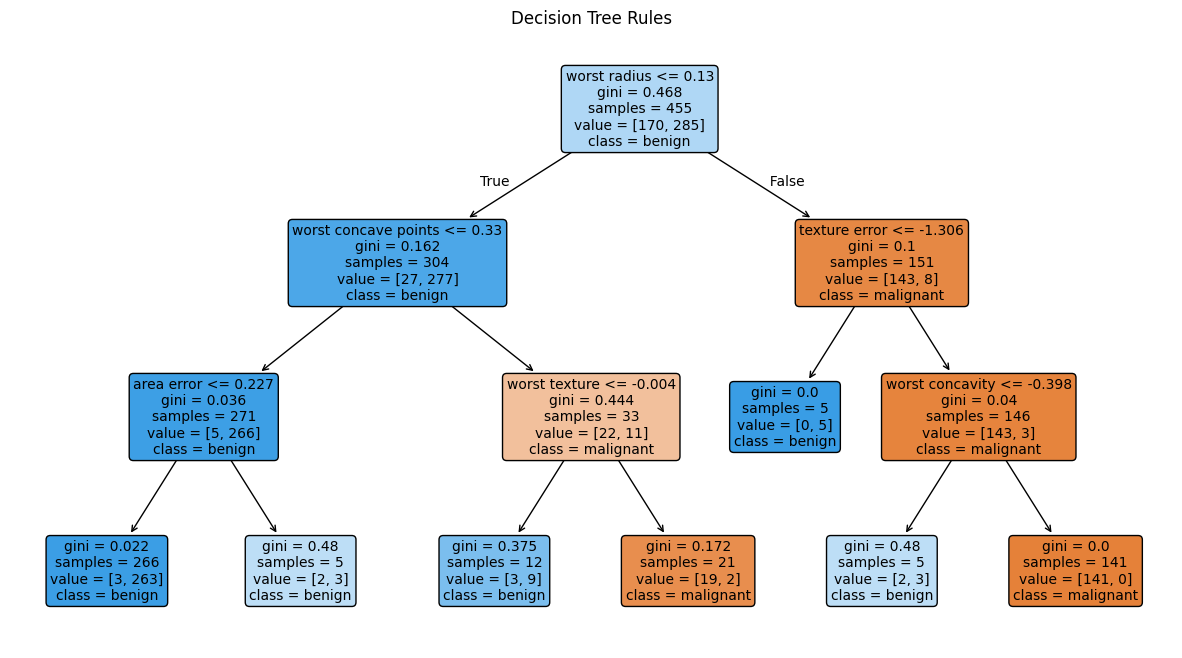

In [44]:
plt.figure(figsize=(15, 8))
# Extract the model from the pipeline to plot it
tree_model = pipeline_dt.named_steps['model']

plot_tree(tree_model, 
          feature_names=X_cls.columns,  # Shows actual names instead of X[0]
          class_names=['malignant', 'benign'], 
          filled=True,                  # Colors nodes by majority class
          rounded=True, 
          fontsize=10)
plt.title("Decision Tree Rules")
plt.show()

### 5. Making a prediction on a Single New Data Point

In [45]:
# Let's pretend a doctor collected these measurements for a new patient
new_patient_data = X_test.iloc[[0]]  # Taking 1 sample for demonstration

# Pass data through pipeline
prediction = pipeline_dt.predict(new_patient_data)
probabilities = pipeline_dt.predict_proba(new_patient_data)

print("Predicted Class:", "Benign" if prediction[0] == 1 else "Malignant")
print(f"Confidence: {probabilities[0].max()*100:.1f}%")

Predicted Class: Malignant
Confidence: 100.0%


### 6. Feature Importance
Which feature was used the most to split the data? Feature importance tells us which inputs are driving the predictions.

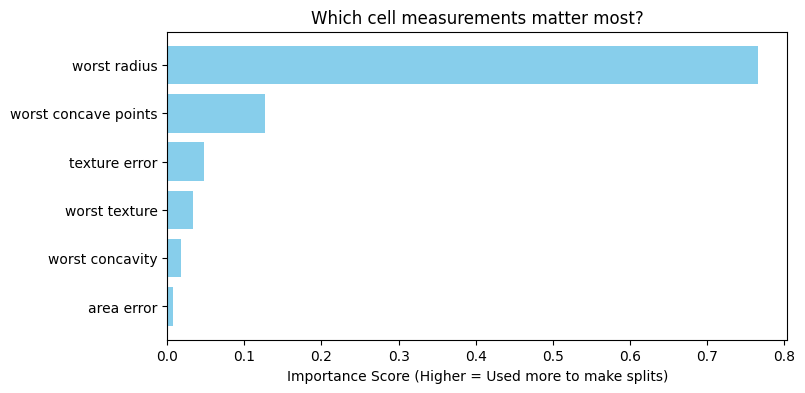

In [46]:
importances = tree_model.feature_importances_

imp_df = pd.DataFrame({'Feature': X_cls.columns, 'Importance': importances})
imp_df = imp_df[imp_df['Importance'] > 0] # Filter out useless features
imp_df = imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 4))
plt.barh(imp_df['Feature'], imp_df['Importance'], color='skyblue')
plt.xlabel("Importance Score (Higher = Used more to make splits)")
plt.title("Which cell measurements matter most?")
plt.gca().invert_yaxis()
plt.show()

---

## Part B — Regression Tree (Predicting a Number)
Instead of predicting a Category (Cancer yes/no), Regression Trees predict a continuous number (e.g. house price, disease progression).

**Key Difference in logic:**
- Classification Tree: A leaf node outputs the **majority vote** (e.g., this node is 90% Class 1).
- Regression Tree: A leaf node outputs the **Average (Mean)** of the samples in that node.

In [47]:
# Load Diabetes Dataset (Predicting disease progression score)
data_reg = load_diabetes(as_frame=True)
X_reg = data_reg.data
y_reg = data_reg.target



# Let's look at the shape of our data
print(f"Total number of (samples): {X_reg.shape[0]}")
print(f"Total number of (features): {X_reg.shape[1]}")
print("\nFirst 5 feature names:", X_reg.columns[:5].tolist())

Total number of (samples): 442
Total number of (features): 10

First 5 feature names: ['age', 'sex', 'bmi', 'bp', 's1']


Root Mean Squared Error: 59.60 (Average prediction error magnitude)


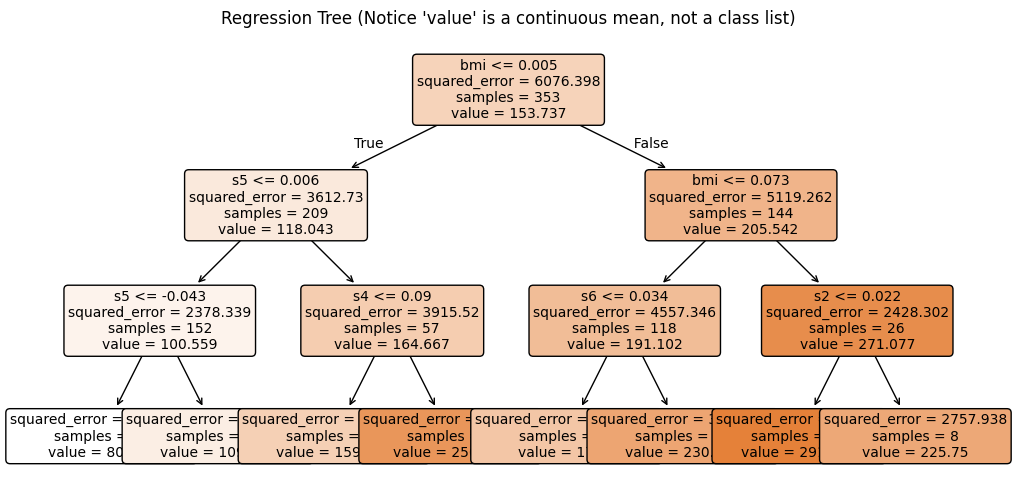

In [48]:

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# 1. Model: Notice we use DecisionTreeRegressor!
reg_tree = DecisionTreeRegressor(max_depth=3, random_state=42)

# 2. Train
reg_tree.fit(X_train_r, y_train_r)

# 3. Predict
y_pred_r = reg_tree.predict(X_test_r)

# 4. Evaluate using RMSE (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
print(f"Root Mean Squared Error: {rmse:.2f} (Average prediction error magnitude)")

# Show tree outputting continuous Values
plt.figure(figsize=(12, 6))
plot_tree(reg_tree, feature_names=X_reg.columns, filled=True, rounded=True, fontsize=10)
plt.title("Regression Tree (Notice 'value' is a continuous mean, not a class list)")
plt.show()

---

## Part C — Cross-Validation: Why Train/Test Split Isn't Always Enough

**The Problem:**
If you just do one `train_test_split`, your model might simply get *lucky* (or unlucky) depending on exactly which rows ended up in the training set versus the test set. Over-tuning to one specific Test Set is a subtle form of overfitting.

**The Solution: K-Fold Cross-Validation**
Instead of splitting the data once, we split it `K` times (usually 5 or 10). 
1. Chop the training data into 5 equal pieces (folds).
2. Train the model on 4 pieces, and test it on the 1 piece left out.
3. Repeat this 5 times, so every piece gets a turn being the 'test' set.
4. Average the 5 scores together to get a much more reliable metric of how good your model actually is.

This gives us deep confidence that our model isn't just getting lucky.

In [49]:
from sklearn.model_selection import cross_val_score

# We will use the base tree we built earlier
cv_tree = DecisionTreeClassifier(max_depth=3, random_state=42)

# Run 5-Fold Cross Validation on the training data
scores = cross_val_score(cv_tree, X_train, y_train, cv=5, scoring='accuracy')

print("Scores for each of the 5 folds:", np.round(scores, 3))
print(f"\nAverage CV Accuracy: {scores.mean():.3f}")
print(f"Score Standard Deviation (Stability): +/- {scores.std():.3f}")

# If the standard deviation is high, the model is very sensitive to exactly which data it trains on!

Scores for each of the 5 folds: [0.934 0.923 0.901 0.901 0.967]

Average CV Accuracy: 0.925
Score Standard Deviation (Stability): +/- 0.024


---

## Part D — GridSearchCV: Finding the *Best* Hyperparameters

How did we know `max_depth=3` was the right choice earlier? The truth is, we didn't. Guessing parameters one by one is slow and ineffective.

**What is GridSearchCV?**
- **Grid:** You give it a "grid" (a dictionary) of different hyperparameters you want to test (e.g., `max_depth`: [2, 3, 4, 5]).
- **Search:** It tries *every single combination* of those parameters.
- **CV (Cross-Validation):** To make sure the score is reliable, it splits the training data into smaller chunks (folds), training on some and validating on others, making sure the model doesn't just get lucky on one specific train/test split.

GridSearchCV automatically finds the optimal combination of settings that yields the highest cross-validated accuracy!

In [50]:
from sklearn.model_selection import GridSearchCV

# 1. Define the Grid of parameters to test
# We'll test depth from 2 to 10, and different min_samples thresholds.
param_grid = {
    'max_depth': [2, 3, 4, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 5, 10]
}

# 2. Initialize a base model
base_tree = DecisionTreeClassifier(random_state=42)

# 3. Set up GridSearchCV
# cv=5 means 5-fold cross-validation
grid_search = GridSearchCV(estimator=base_tree, param_grid=param_grid, cv=5, scoring='accuracy')

# 4. Fit the GridSearch to the training data (This will run many models!)
print("Starting Grid Search (testing combinations)...")
grid_search.fit(X_train, y_train)

# 5. See the results!
print("\n--- Grid Search Results ---")
print(f"Best Accuracy Score (CV): {grid_search.best_score_:.3f}")
print("Best Hyperparameters Found:")
print(grid_search.best_params_)

# 6. Use the best model on our hidden Test Set
best_model = grid_search.best_estimator_
final_test_accuracy = best_model.score(X_test, y_test)
print(f"\nFinal Test Accuracy with tuned model: {final_test_accuracy:.3f}")

Starting Grid Search (testing combinations)...

--- Grid Search Results ---
Best Accuracy Score (CV): 0.938
Best Hyperparameters Found:
{'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2}

Final Test Accuracy with tuned model: 0.939
